# Rule-Based Baseline and HDAR

COMP9444 Project 003 classifies FOMC sentences as **Dovish (0)**,
**Hawkish (1)**, or **Neutral (2)**. This notebook contains the Rule-Based
paper baseline and the HDAR model.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.fomc_experiment import LABEL_NAMES, load_split, rule_based_predict_one

pd.set_option("display.max_colwidth", 100)

## Data

The labelled splits come from the
[FOMC hawkish/dovish dataset](https://github.com/gtfintechlab/fomc-hawkish-dovish/tree/main/training_data/test-and-training).
The group repository supplies augmented training rows. Test files remain raw.

In [2]:
summary = pd.read_csv(ROOT / "results" / "eda_dataset_summary.csv")
classes = pd.read_csv(ROOT / "results" / "eda_class_distribution.csv")

display(summary[summary["seed"] == 5768])
display(
    classes[
        (classes["seed"] == 5768)
        & (classes["split"].isin(["raw_train", "raw_test"]))
    ][["split", "class_name", "count", "proportion"]]
)

,seed,split,rows,dovish,hawkish,neutral,year_min,year_max,unique_years,mean_words,median_words,max_words
0,5768,raw_train,1903,498,476,929,1996,2022,27,31.39,29.0,181
1,5768,raw_test,476,127,124,225,1996,2022,27,32.14,30.0,136
2,5768,augmented_train_file,5159,1599,1475,2085,1996,2022,27,31.69,29.0,510


,split,class_name,count,proportion
0,raw_train,Dovish,498,0.2617
1,raw_train,Hawkish,476,0.2501
2,raw_train,Neutral,929,0.4882
3,raw_test,Dovish,127,0.2668
4,raw_test,Hawkish,124,0.2605
5,raw_test,Neutral,225,0.4727


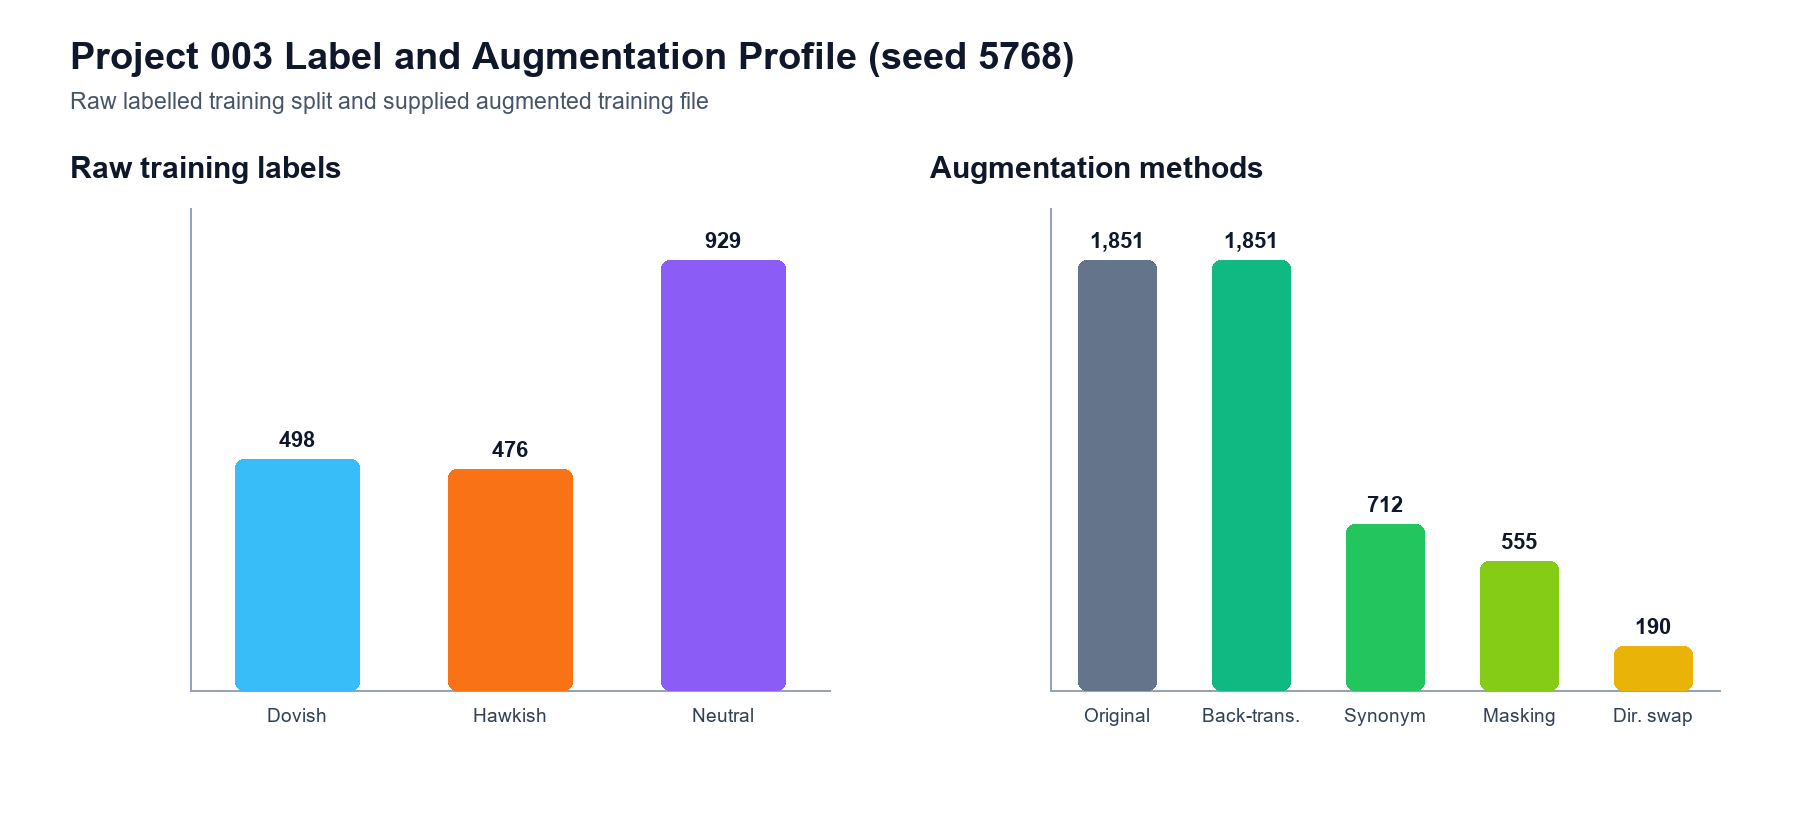

In [3]:
display(
    Image(
        filename=str(ROOT / "results" / "eda_label_augmentation_profile.png"),
        width=950,
    )
)

Neutral is the largest class, so weighted F1 is reported together
with macro F1 and per-class F1. Augmented rows stay in training only.

## Split check

In [4]:
audits = pd.DataFrame(
    [load_split(seed).audit() for seed in (5768, 78516, 944601)]
)
overlap_columns = [
    "train_validation_group_overlap",
    "train_validation_text_overlap",
    "train_test_text_overlap",
    "validation_test_text_overlap",
]
audits["all_overlap_count"] = audits[overlap_columns].sum(axis=1)
audits[
    [
        "seed",
        "train_original_rows",
        "train_augmented_rows",
        "validation_rows",
        "test_rows",
        "all_overlap_count",
    ]
]

,seed,train_original_rows,train_augmented_rows,validation_rows,test_rows,all_overlap_count
0,5768,1481,4123,370,476,0
1,78516,1485,4148,368,476,0
2,944601,1481,4125,372,476,0


Each seed has its own validation split. A configuration selected on
one seed is used only for that seed's raw test set. Source families are grouped
before validation, and exact text overlap is rejected.

## Models

### Rule-Based

The implementation follows the paper's
[released rule code](https://github.com/gtfintechlab/fomc-hawkish-dovish/blob/main/code_model/rule_based.py):
dictionary terms are checked as lowercase substrings, Dovish conditions are
checked before Hawkish conditions, Panel C reverses direction, and unmatched
sentences are Neutral.

In [5]:
examples = [
    "Inflation continued to decline.",
    "Inflation continued to rise.",
    "Inflation did not increase.",
    "The meeting ended at noon.",
]
for sentence in examples:
    prediction, matches = rule_based_predict_one(sentence)
    print(f"{LABEL_NAMES[prediction]:7s} | {sentence} | {matches}")

Dovish  | Inflation continued to decline. | {'A1': ['inflation'], 'B1': [], 'A2': ['decline'], 'B2': [], 'C': []}
Hawkish | Inflation continued to rise. | {'A1': ['inflation'], 'B1': [], 'A2': [], 'B2': ['rise'], 'C': []}
Dovish  | Inflation did not increase. | {'A1': ['inflation'], 'B1': [], 'A2': [], 'B2': ['ease', 'increase'], 'C': ['did not']}
Neutral | The meeting ended at noon. | {'A1': [], 'B1': [], 'A2': [], 'B2': [], 'C': []}


### HDAR

HDAR combines word and character TF-IDF features with explicit monetary-policy
direction features. A cosine-neighbour memory is blended with a three-class
branch and a Neutral-versus-Directional hierarchy branch.

In [6]:
selected = json.loads(
    (ROOT / "results" / "selected_configs.json").read_text(encoding="utf-8")
)
pd.DataFrame(
    [
        {
            "seed": int(seed),
            "LR n-gram": str(config["tfidf_logistic_regression"]["word_ngram"]),
            "HDAR hierarchy weight": config["hdar_ensemble_augmented"][
                "hierarchy_weight"
            ],
            "HDAR neutral bias": config["hdar_ensemble_augmented"][
                "neutral_bias"
            ],
        }
        for seed, config in selected.items()
    ]
)

,seed,LR n-gram,HDAR hierarchy weight,HDAR neutral bias
0,5768,"[1, 1]",0.1,0.85
1,78516,"[1, 2]",0.0,0.95
2,944601,"[1, 1]",0.2,0.90


## Experiment

Models are evaluated on raw test rows for seeds 5768, 78516, and 944601.
Weighted F1 is the primary metric; macro F1, accuracy, class F1, predictions,
and confusion matrices are also saved.

In [7]:
aggregate = pd.read_csv(ROOT / "results" / "aggregate_results.csv")
columns = [
    "model_name",
    "weighted_f1_mean",
    "weighted_f1_std",
    "macro_f1_mean",
    "accuracy_mean",
    "dovish_f1_mean",
    "hawkish_f1_mean",
    "neutral_f1_mean",
]
aggregate[columns].round(4)

,model_name,weighted_f1_mean,weighted_f1_std,macro_f1_mean,accuracy_mean,dovish_f1_mean,hawkish_f1_mean,neutral_f1_mean
0,direction_retrieval_augmented,0.5436,0.0326,0.5127,0.5462,0.4223,0.4639,0.6518
1,hdar_ensemble_augmented,0.5412,0.0372,0.5102,0.5427,0.4196,0.4616,0.6494
2,hdar_augmented,0.5166,0.0393,0.4841,0.5217,0.3969,0.4258,0.6297
3,hierarchical_direction_raw,0.5136,0.0363,0.4756,0.5252,0.3558,0.4265,0.6446
4,hierarchical_direction_augmented,0.5123,0.0362,0.4745,0.5238,0.3583,0.4218,0.6433
5,tfidf_logistic_regression,0.5113,0.0446,0.4819,0.5203,0.4095,0.4246,0.6117
6,tfidf_linear_svm,0.5110,0.0332,0.4930,0.5063,0.4427,0.4639,0.5723
7,hierarchical_augmented,0.5010,0.0239,0.4714,0.5049,0.4126,0.3954,0.6061
8,rule_based,0.4991,0.0060,0.4618,0.5000,0.4225,0.3355,0.6276
9,stratified_random,0.3668,0.0029,0.3389,0.3669,0.2823,0.2710,0.4633


In [8]:
rows = []
for seed in (5768, 78516, 944601):
    row = {"seed": seed}
    for label, model in [
        ("HDAR", "hdar_ensemble_augmented"),
        ("Logistic Regression", "tfidf_logistic_regression"),
        ("Rule-Based", "rule_based"),
    ]:
        metrics = json.loads(
            (
                ROOT / "results" / model / f"seed_{seed}" / "metrics.json"
            ).read_text(encoding="utf-8")
        )
        row[f"{label} weighted F1"] = metrics["weighted_f1"]
        row[f"{label} macro F1"] = metrics["macro_f1"]
    rows.append(row)

per_seed = pd.DataFrame(rows)
per_seed["HDAR - LR"] = (
    per_seed["HDAR weighted F1"]
    - per_seed["Logistic Regression weighted F1"]
)
per_seed.round(4)

,seed,HDAR weighted F1,HDAR macro F1,Logistic Regression weighted F1,Logistic Regression macro F1,Rule-Based weighted F1,Rule-Based macro F1,HDAR - LR
0,5768,0.5631,0.5376,0.5589,0.5471,0.5055,0.4712,0.0042
1,78516,0.5622,0.5307,0.4705,0.4373,0.4936,0.4523,0.0917
2,944601,0.4982,0.4624,0.5044,0.4613,0.4981,0.4621,-0.0062


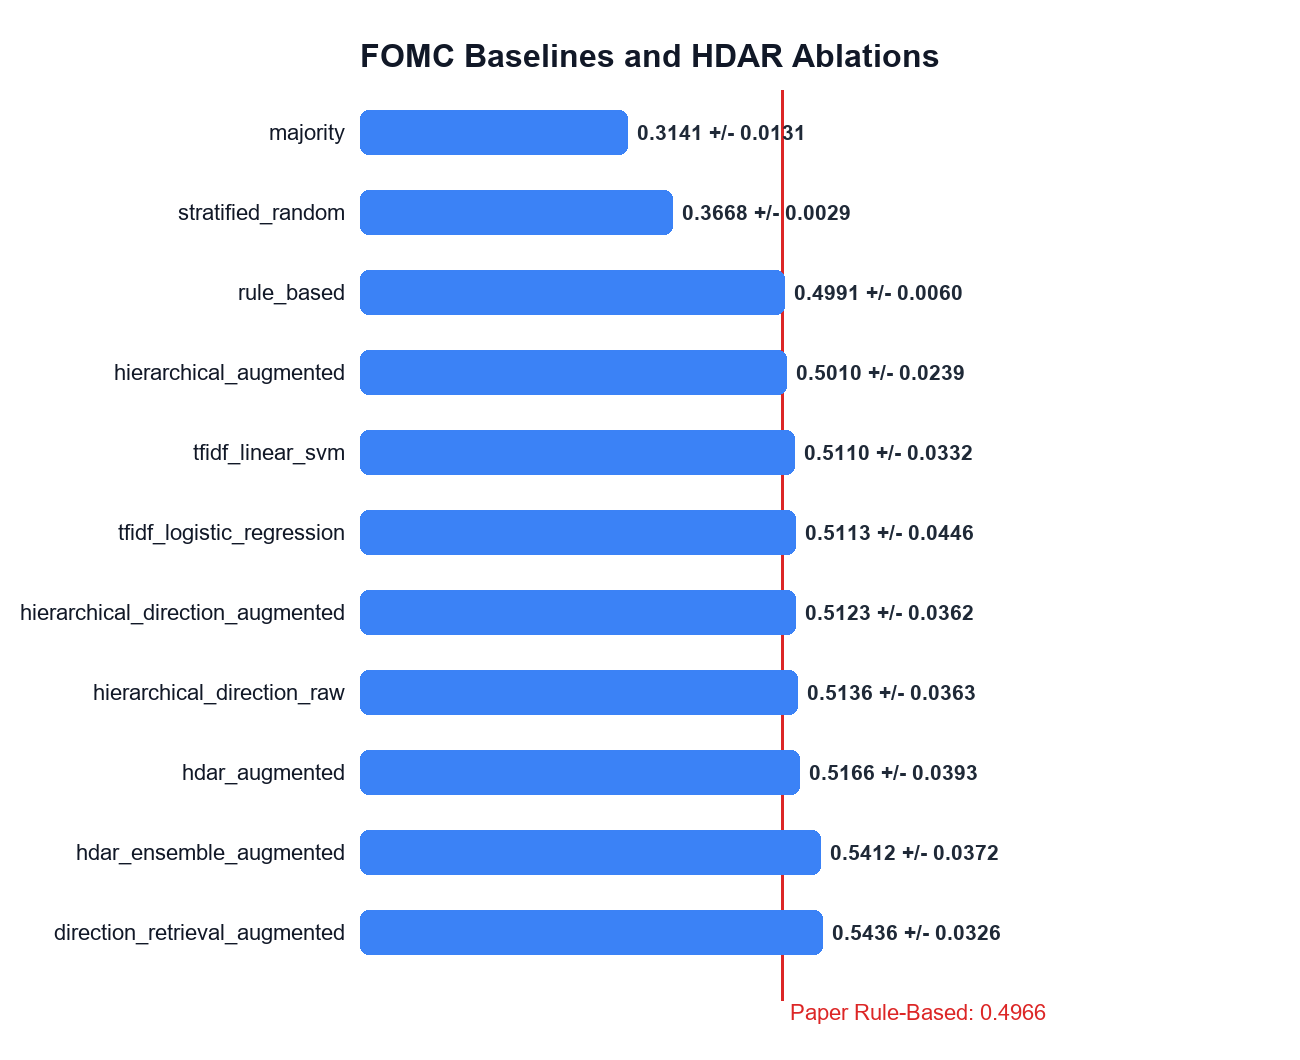

In [9]:
display(
    Image(
        filename=str(ROOT / "results" / "weighted_f1_comparison.png"),
        width=900,
    )
)

## Discussion

In [10]:
hdar = aggregate.set_index("model_name").loc["hdar_ensemble_augmented"]
lr = aggregate.set_index("model_name").loc["tfidf_logistic_regression"]
rule = aggregate.set_index("model_name").loc["rule_based"]

seed_wins = int((per_seed["HDAR - LR"] > 0).sum())
worst = per_seed.loc[per_seed["HDAR - LR"].idxmin()]
weighted_gap = hdar["weighted_f1_mean"] - lr["weighted_f1_mean"]
macro_gap = hdar["macro_f1_mean"] - lr["macro_f1_mean"]

display(
    Markdown(
        f"""HDAR and Logistic Regression are broadly comparable across the
three splits. HDAR is higher on **{seed_wins}/3 seeds** and lower by
**{abs(worst['HDAR - LR']):.4f}** on seed **{int(worst['seed'])}**. Its mean
weighted F1 is higher by **{weighted_gap:.4f}**, but the gain is concentrated
in one split, so it is not a stable improvement. Mean macro F1 is
**{macro_gap:+.4f}** relative to Logistic Regression.

The Rule-Based mean weighted F1 is **{rule['weighted_f1_mean']:.4f}**, close to
the paper's reported **0.4966**."""
    )
)

HDAR and Logistic Regression are broadly comparable across the
three splits. HDAR is higher on **2/3 seeds** and lower by
**0.0062** on seed **944601**. Its mean
weighted F1 is higher by **0.0299**, but the gain is concentrated
in one split, so it is not a stable improvement. Mean macro F1 is
**+0.0283** relative to Logistic Regression.

The Rule-Based mean weighted F1 is **0.4991**, close to
the paper's reported **0.4966**.

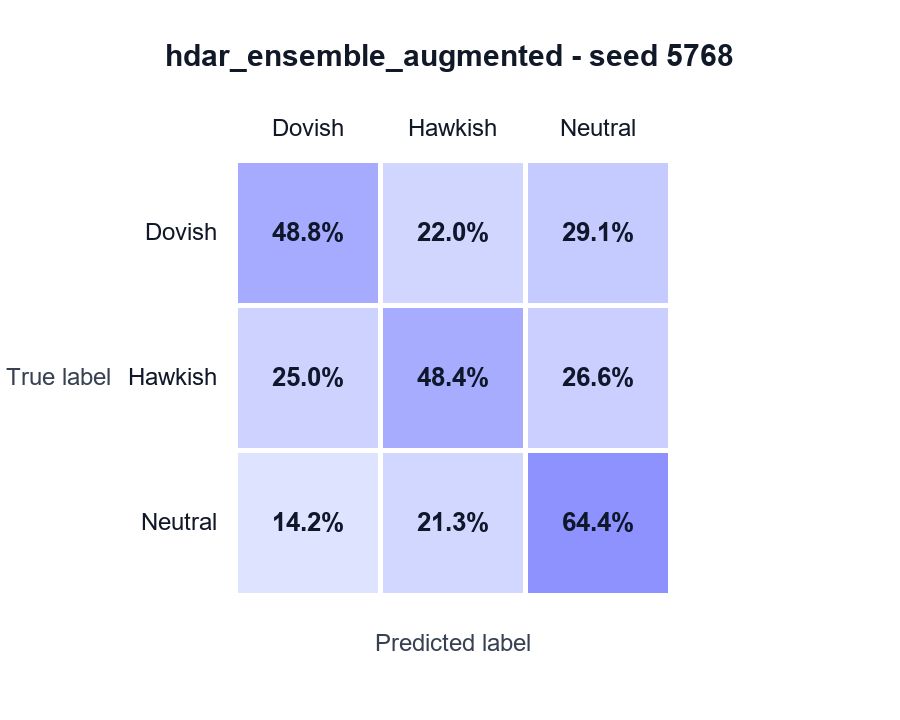

In [11]:
display(
    Image(
        filename=str(
            ROOT
            / "results"
            / "hdar_ensemble_augmented"
            / "seed_5768"
            / "confusion_matrix_normalized.png"
        ),
        width=620,
    )
)

## Error analysis

In [12]:
errors = pd.read_csv(ROOT / "results" / "hdar_error_analysis.csv")
errors[
    [
        "sentence",
        "true_label",
        "predicted_label",
        "confidence",
        "error_category",
    ]
].head(10)

,sentence,true_label,predicted_label,confidence,error_category
0,"That said, many of my colleagues and I would see a portion of the decline in the unemployment ra...",1,0,0.762025,negation
1,"The drop in the unemployment rate over the past year, while welcome and significant, could overs...",2,0,0.712074,employment direction
2,"Retail energy prices were likely to retrace at least a portion of the post-hurricane increase, a...",2,1,0.677020,inflation direction
3,"In the past few years, the effect on the dollar of increased expectations about divergence betwe...",0,1,0.655241,inflation direction
4,"Thus, reducing vacancies from an extremely high level to a lower (but still strong) level has a ...",2,1,0.622949,employment direction
5,If incoming information broadly supports the Committee's expectation of ongoing improvement in l...,1,0,0.601413,mixed inflation/employment
6,"However, in this framework, the current period appears to be an outlier.4 That is, even after fa...",2,1,0.591048,implicit or mixed stance
7,"If, in their quest to reduce macroeconomic risk, policymakers overshoot and ease policy too much...",1,0,0.590446,implicit or mixed stance
8,But overly optimistic expectations for long-run earnings growth were not being driven by easy mo...,1,2,0.550542,negation
9,"That is, it was thought that by accepting a modest increase in the inflation rate, policy could ...",0,1,0.545532,mixed inflation/employment


The main failures involve negation scope, mixed inflation and
employment directions, and sentences whose stance is implicit. Keyword
features and local neighbours help, but they do not resolve these cases
consistently. The three seeds are alternative splits of a small labelled
dataset, so the mean result should not be treated as a general performance
guarantee.